### HW Thresholds computation

In [17]:
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from skimage.measure import block_reduce
from pyproj import Transformer
import numpy as np
import seaborn as sns
import pandas as pd
import os

plt.rcParams.update({'font.size': 18})

In [11]:
thresh_path = '../data/CERRA-ERA5/test_samples/thresholds.nc4c'

if os.path.exists(thresh_path):
    thresholds = xr.open_dataset(thresh_path, engine='netcdf4').to_dataarray()[0]
else:
    data_path = "../data/CERRA-ERA5/CERRA_max"

    cerra = []
    for year in range(1985, 2015):
        for month in range(1, 13):
            ds = xr.open_dataset(data_path + f'/{year}/max/cerra_t2m_max_{year}{month:02d}.nc4c', engine='netcdf4')
            cerra.append(ds['2t'])

    cerra = xr.concat(cerra, dim='time')

    # Convert from Kelvin to Celsius
    cerra = cerra - 273.15

    # Homogenize dimensions
    cerra = cerra.isel(height=0)
    cerra=cerra.resample(time='D').mean()
    thresholds=cerra.quantile(0.95, dim='time')

In [15]:
# Points of study

study_points = pd.DataFrame(
    data=[
        {'feature':'City', 'name':'Hamburg', 'lon':9.975, 'lat':53.575, 'x':np.nan, 'y':np.nan},   
        {'feature':'Island', 'name':'Bornholm', 'lon':14.875, 'lat':55.175, 'x':np.nan, 'y':np.nan},
        {'feature':'Plain', 'name':'Uckermark', 'lon':14.175, 'lat':53.225, 'x':np.nan, 'y':np.nan},
        {'feature':'Valley', 'name':'Bø', 'lon':9.075, 'lat':59.375, 'x':np.nan, 'y':np.nan},    
    ]
)
nb_points = len(study_points)

study_points

,feature,name,lon,lat,x,y
0,City,Hamburg,9.975,53.575,NaN,NaN
1,Island,Bornholm,14.875,55.175,NaN,NaN
2,Plain,Uckermark,14.175,53.225,NaN,NaN
3,Valley,Bø,9.075,59.375,NaN,NaN


<Figure size 640x480 with 0 Axes>

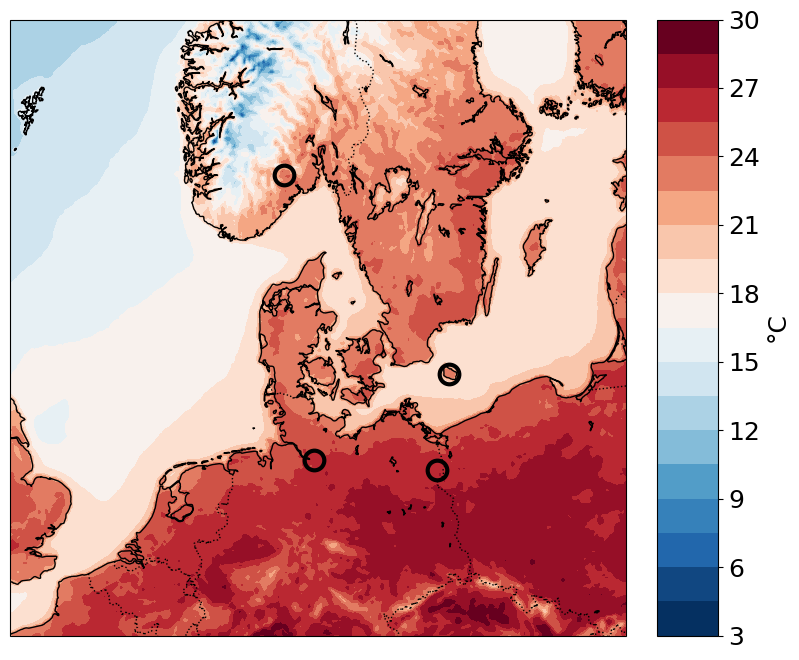

In [20]:
# Plotting params
cmaps = ["RdBu_r"]
plot_varnames = ["Temperature"]
plot_var_labels = ["°C"]

# Projection and coordinates
transformer = Transformer.from_crs(
   "EPSG:4326",  # WGS84 lon/lat
   "+proj=lcc +lat_0=50 +lon_0=8 +lat_1=50 +lat_2=50 +R=6371229 +units=m",
   always_xy=True
)

lon0 = ds['Lambert_Conformal'].attrs['longitudeOfFirstGridPointInDegrees']
lat0 = ds['Lambert_Conformal'].attrs['latitudeOfFirstGridPointInDegrees']

x0, y0 = transformer.transform(lon0, lat0)

lambert_proj = ccrs.LambertConformal(
   central_longitude=8,
   central_latitude=50,
   standard_parallels=(50, 50),
   globe=ccrs.Globe(ellipse='sphere', semimajor_axis=6371229.0),
   false_easting=-x0,
   false_northing=-y0
)

plt.clf()

fig, ax= plt.subplots(1, 1, figsize=(8, 8),
                         subplot_kw={'projection': lambert_proj})

# Fitted
vmax = thresholds.max()
vmin = thresholds.min()
# ax.set_title('Thresholds map', fontsize=16)
pcm = ax.contourf(thresholds.x, thresholds.y, thresholds,
                  vmin=vmin, vmax=vmax,
                  cmap='RdBu_r', levels=20, transform=lambert_proj)
# ax.grid(True, alpha=0.3)
ax.coastlines()
ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none') # type: ignore
ax.add_feature(cartopy.feature.BORDERS, linestyle=':') # type: ignore
cax = ax.inset_axes((1.05, 0., .1, 1.))
plt.colorbar(pcm, cax=cax, orientation="vertical", label=f"{plot_var_labels[0]}")

# Add study points
for i in range(nb_points):
    x_pt, y_pt = transformer.transform(study_points['lon'][i], study_points['lat'][i])
    study_points.at[i, 'x'] = x_pt-x0
    study_points.at[i, 'y'] = y_pt

ax.scatter(study_points['x'], study_points['y'],
         fc='#00000000', s=200, marker='o', lw=3, ec="k",
         transform=lambert_proj, zorder=10)

# plt.tight_layout()
plt.show()


In [8]:
thresholds.to_netcdf('../data/CERRA-ERA5/test_samples/thresholds.nc4c')